## Data Understanding

In [1]:
# Phase 1: Environment Setup & Raw Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import re
import warnings

warnings.filterwarnings('ignore')

# Set plotting style for professional reports
plt.style.use('seaborn-v0_8-muted')
sns.set_palette("viridis")

print("Libraries loaded successfully.")

Libraries loaded successfully.


### Helper functions for Census and SAT data

#### Census cleaning function (double‑header handling)

In [2]:
def clean_census_file(filepath, report_type):
    """
    Cleans DP02 or DP03 Census files based on ACS naming convention.
    Example filename: ACSDP1Y2019.DP02-Data.csv

    - Extracts year from filename
    - Drops the first metadata row
    - Standardizes 'NAME' -> 'state'
    - Adds 'year' column
    """
    filename = os.path.basename(filepath)
    # Extract year from filename (e.g., ACSDP1Y2019.DP02-Data.csv)
    year_str = ''.join(filter(str.isdigit, filename.split('.')[0]))
    year = int(year_str)

    df = pd.read_csv(filepath, low_memory=False)
    df_clean = df.drop(0).reset_index(drop=True)

    if 'NAME' in df_clean.columns:
        df_clean = df_clean.rename(columns={'NAME': 'state'})

    df_clean['year'] = year
    df_clean['state'] = df_clean['state'].astype(str).str.strip().str.title()

    return df_clean


#### Census feature extraction

In [3]:
def extract_key_features(df, report_type):
    """
    Extracts only the key ACS features needed for this analysis.

    For DP03 (Economic):
        - DP03_0062E  -> median_income
        - DP03_0128PE -> poverty_rate (% families below poverty)

    For DP02 (Social):
        - DP02_0068PE -> pct_bachelors_higher (% with Bachelor's+)
    """
    if 'DP03' in report_type:
        mapping = {
            'DP03_0062E': 'median_income',
            'DP03_0128PE': 'poverty_rate',
        }
    else:
        mapping = {
            'DP02_0068PE': 'pct_bachelors_higher',
        }

    # Ensure state/year present
    if 'state' not in df.columns:
        if 'NAME' in df.columns:
            df = df.rename(columns={'NAME': 'state'})

    existing_cols = [col for col in mapping.keys() if col in df.columns]
    df_sub = df[['state', 'year'] + existing_cols].copy()
    df_sub = df_sub.rename(columns=mapping)

    for col in df_sub.columns:
        if col not in ['state', 'year']:
            df_sub[col] = pd.to_numeric(df_sub[col], errors='coerce')

    return df_sub


#### SAT IQR extraction (from pre‑converted CSVs)

In [4]:
def extract_top_sat_iqr(folder_path):
    """
    Extracts the top 10 states with the highest SAT IQR spread from CSV files
    converted from PDFs. Assumes columns:
        - 'SAT_25th_Total'
        - 'SAT_75th_Total'
        - 'State'
    """
    all_data = []
    for filename in os.listdir(folder_path):
        if filename.endswith('.csv'):
            file_path = os.path.join(folder_path, filename)
            df = pd.read_csv(file_path)

            if 'SAT_25th_Total' in df.columns and 'SAT_75th_Total' in df.columns:
                df['SAT_IQR_Spread'] = df['SAT_75th_Total'] - df['SAT_25th_Total']
                all_data.append(df[['State', 'SAT_IQR_Spread']])

    if not all_data:
        return pd.DataFrame(columns=['State', 'SAT_IQR_Spread'])

    combined_df = pd.concat(all_data, ignore_index=True)
    top_sat_iqr_df = combined_df.sort_values(by='SAT_IQR_Spread', ascending=False).head(10)
    return top_sat_iqr_df


### Load SAT data (College Board)

In [5]:
# Identifying all College Board files using the naming pattern
cb_files = glob.glob('data/sat_comprehensive_final_*.csv')
cb_list = []

for file in cb_files:
    year_match = re.search(r'(\d{4})', file)
    year = int(year_match.group(1)) if year_match else None

    df_temp = pd.read_csv(file, low_memory=False)
    df_temp['Year'] = year
    cb_list.append(df_temp)

df_sat_master = pd.concat(cb_list, ignore_index=True)

# Standardize column names
df_sat_master.columns = [col.strip().lower() for col in df_sat_master.columns]

print(f"Loaded {len(cb_files)} SAT files. Master shape: {df_sat_master.shape}")
display(df_sat_master.head())
display(df_sat_master.describe(include='all'))


Loaded 6 SAT files. Master shape: (318, 248)


,year,state,total_sat_takers,total_participation_rate,mean_total_score,mean_erw_score,mean_math_score,race_asian_n,race_asian_pct,race_asian_mean_tot,...,inc_highest_met_erw,inc_highest_met_math,inc_unknown_n,inc_unknown_pct,inc_unknown_mean_tot,inc_unknown_mean_erw,inc_unknown_mean_math,inc_unknown_met_both,inc_unknown_met_erw,inc_unknown_met_math
0,2019,Alabama,3240,0.07,1143,583,560,282,0.09,1302,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019,Alaska,3212,0.41,1097,556,541,314,0.10,1065,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019,Arizona,21472,0.31,472,1134,569,1646,0.08,1262,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019,Arkansas,1790,0.06,790,1141,582,131,0.07,1254,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019,California,272892,0.63,892,1065,534,46827,0.17,1214,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,year,state,total_sat_takers,total_participation_rate,mean_total_score,mean_erw_score,mean_math_score,race_asian_n,race_asian_pct,race_asian_mean_tot,...,inc_highest_met_erw,inc_highest_met_math,inc_unknown_n,inc_unknown_pct,inc_unknown_mean_tot,inc_unknown_mean_erw,inc_unknown_mean_math,inc_unknown_met_both,inc_unknown_met_erw,inc_unknown_met_math
count,318.000000,318,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,...,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
unique,NaN,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Alabama,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2021.500000,NaN,32421.569182,0.397893,692.795597,799.418239,479.562893,2660.550314,0.091101,1152.103774,...,0.581950,0.467673,3267.427673,0.091132,649.786164,329.735849,320.088050,0.227421,0.371069,0.241258
std,1.710517,NaN,54088.361176,0.365322,374.018985,400.505774,192.805211,5629.839799,0.068768,292.038887,...,0.417869,0.348429,8346.203055,0.114356,488.339260,247.504186,241.000168,0.227282,0.318439,0.238414
min,2019.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2020.000000,NaN,1288.250000,0.030000,439.750000,546.750000,495.000000,146.250000,0.040000,1153.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2021.500000,NaN,7900.000000,0.300000,722.500000,988.000000,538.500000,389.500000,0.080000,1213.000000,...,0.810000,0.590000,137.000000,0.080000,903.000000,462.000000,444.000000,0.170000,0.370000,0.180000
75%,2023.000000,NaN,43283.250000,0.707500,987.000000,1116.750000,592.750000,2620.000000,0.130000,1287.500000,...,0.920000,0.770000,2509.000000,0.130000,1052.000000,528.000000,517.000000,0.420000,0.660000,0.450000


### Load Census data (DP02 & DP03)

In [6]:
print(f"Current Directory: {os.getcwd()}")

dp02_files = sorted(glob.glob('data/census/DP02/ACSDP1Y*.DP02-Data.csv'))
dp03_files = sorted(glob.glob('data/census/DP03/ACSDP1Y*.DP03-Data.csv'))

print(f"DP02 Files Found: {len(dp02_files)}")
print(f"DP03 Files Found: {len(dp03_files)}")


Current Directory: d:\WorkArea\PJ-SPIM
DP02 Files Found: 5
DP03 Files Found: 5


In [8]:
census_master_list = []

for f2 in dp02_files:
    base_name = os.path.basename(f2).split('.')[0]  # e.g., ACSDP1Y2019
    f3 = next((f for f in dp03_files if base_name in os.path.basename(f)), None)

    if not f3:
        print(f"Skipping: No matching DP03 file found for {base_name}")
        continue

    try:
        year_val = base_name[-4:]
        print(f"\nMatched! Processing Year: {year_val}")

        df2_raw = clean_census_file(f2, 'DP02')
        df3_raw = clean_census_file(f3, 'DP03')

        feat2 = extract_key_features(df2_raw, 'DP02')
        feat3 = extract_key_features(df3_raw, 'DP03')

        # Force alignment
        target_year = int(year_val)
        feat2['year'] = target_year
        feat3['year'] = target_year

        feat2['state'] = feat2['state'].astype(str).str.strip().str.title()
        feat3['state'] = feat3['state'].astype(str).str.strip().str.title()

        yr_combined = pd.merge(feat2, feat3, on=['state', 'year'], how='inner')

        if not yr_combined.empty:
            census_master_list.append(yr_combined)
            print(f"Success! {year_val} combined shape: {yr_combined.shape}")
        else:
            print(f"--- Merge failed for {year_val} (empty result) ---")

    except Exception as e:
        print(f"Error processing {base_name}: {e}")

if census_master_list:
    df_census_master = pd.concat(census_master_list, ignore_index=True)
    print(f"\nFinal Census Master Shape: {df_census_master.shape}")
    print("Final Census Master Years:", sorted(df_census_master['year'].unique().tolist()))
else:
    df_census_master = pd.DataFrame()
    print("\n--- Error ---")
    print("No valid Census pairs were found.")



Matched! Processing Year: 2019
Success! 2019 combined shape: (52, 5)

Matched! Processing Year: 2021
Success! 2021 combined shape: (52, 5)

Matched! Processing Year: 2022
Success! 2022 combined shape: (52, 5)

Matched! Processing Year: 2023
Success! 2023 combined shape: (52, 5)

Matched! Processing Year: 2024
Success! 2024 combined shape: (52, 5)

Final Census Master Shape: (260, 5)
Final Census Master Years: [2019, 2021, 2022, 2023, 2024]


## Data Preparation

### SAT cleaning and target variable setup

In [9]:
# Ensure key columns exist and are numeric
df_sat_master = df_sat_master.dropna(subset=['state', 'year'])

# Normalize column names for target
df_sat_master.columns = df_sat_master.columns.str.strip().str.lower()

# Try to standardize mean_total
if 'mean_total' not in df_sat_master.columns:
    potential_names = ['mean_tot', 'total_sat_mean', 'total_mean', 'mean_total_score']
    for name in potential_names:
        if name in df_sat_master.columns:
            df_sat_master.rename(columns={name: 'mean_total'}, inplace=True)
            print(f"Renamed {name} to mean_total")
            break

if 'mean_total' in df_sat_master.columns:
    df_sat_master['mean_total'] = pd.to_numeric(df_sat_master['mean_total'], errors='coerce')

print("Final SAT columns:", df_sat_master.columns.tolist())

Renamed mean_total_score to mean_total
Final SAT columns: ['year', 'state', 'total_sat_takers', 'total_participation_rate', 'mean_total', 'mean_erw_score', 'mean_math_score', 'race_asian_n', 'race_asian_pct', 'race_asian_mean_tot', 'race_asian_mean_erw', 'race_asian_mean_math', 'race_asian_met_both', 'race_asian_met_erw', 'race_asian_met_math', 'race_black_n', 'race_black_pct', 'race_black_mean_tot', 'race_black_mean_erw', 'race_black_mean_math', 'race_black_met_both', 'race_black_met_erw', 'race_black_met_math', 'race_hispanic_n', 'race_hispanic_pct', 'race_hispanic_mean_tot', 'race_hispanic_mean_erw', 'race_hispanic_mean_math', 'race_hispanic_met_both', 'race_hispanic_met_erw', 'race_hispanic_met_math', 'race_white_n', 'race_white_pct', 'race_white_mean_tot', 'race_white_mean_erw', 'race_white_mean_math', 'race_white_met_both', 'race_white_met_erw', 'race_white_met_math', 'race_multi_n', 'race_multi_pct', 'race_multi_mean_tot', 'race_multi_mean_erw', 'race_multi_mean_math', 'race_mul

In [10]:
# If mean_total is corrupted, we will use sat_50th_total as the target
target_col = 'sat_50th_total' if 'sat_50th_total' in df_sat_master.columns else 'mean_total'
print(f"Selected target variable: {target_col}")

Selected target variable: sat_50th_total


### Census cleaning and alignment

In [11]:
# Basic sanity check
display(df_census_master.head())
display(df_census_master.describe(include='all'))

,state,year,pct_bachelors_higher,median_income,poverty_rate
0,Alabama,2019,26.3,51734,15.5
1,Alaska,2019,30.2,75463,10.1
2,Arizona,2019,30.2,62055,13.5
3,Arkansas,2019,23.3,48952,16.2
4,California,2019,35.0,80440,11.8


,state,year,pct_bachelors_higher,median_income,poverty_rate
count,260,260.000000,255.000000,260.000000,260.000000
unique,52,NaN,NaN,NaN,NaN
top,Alabama,NaN,NaN,NaN,NaN
freq,5,NaN,NaN,NaN,NaN
mean,NaN,2021.800000,34.948235,72695.284615,12.809231
std,NaN,1.723783,6.863224,14877.307955,4.680634
min,NaN,2019.000000,21.100000,20474.000000,7.200000
25%,NaN,2021.000000,30.550000,63187.250000,10.375000
50%,NaN,2022.000000,34.200000,72052.500000,11.900000
75%,NaN,2023.000000,38.000000,82114.750000,13.600000


### Merge SAT + Census

In [12]:
df_sat_census = pd.merge(
    df_sat_master,
    df_census_master,
    on=['state', 'year'],
    how='inner'
)

print(f"Combined SAT-Census Shape: {df_sat_census.shape}")
print("Missing Values Check:\n", df_sat_census[['median_income']].isna().sum())


Combined SAT-Census Shape: (260, 251)
Missing Values Check:
 median_income    0
dtype: int64


In [13]:
expected_rows = 50 * len(df_census_master['year'].unique())
print(f"Final records: {len(df_sat_census)} (Expected approx {expected_rows})")

df_sat_census.to_csv('data/New_SAT_Census_Merged_v1.csv', index=False)
print("Merged dataset saved to data/New_SAT_Census_Merged_v1.csv")

Final records: 260 (Expected approx 250)
Merged dataset saved to data/New_SAT_Census_Merged_v1.csv


### Final numeric cleanup

In [14]:
cols_to_fix = ['median_income', 'pct_bachelors_higher', 'poverty_rate', target_col]

for col in cols_to_fix:
    if col in df_sat_census.columns:
        df_sat_census[col] = pd.to_numeric(df_sat_census[col], errors='coerce')

df_final = df_sat_census.dropna(subset=[c for c in cols_to_fix if c in df_sat_census.columns])
df_final = df_final.replace([np.inf, -np.inf], np.nan).dropna(subset=cols_to_fix)

print("Final modeling dataset shape:", df_final.shape)
display(df_final.head())


Final modeling dataset shape: (255, 251)


,year,state,total_sat_takers,total_participation_rate,mean_total,mean_erw_score,mean_math_score,race_asian_n,race_asian_pct,race_asian_mean_tot,...,inc_unknown_pct,inc_unknown_mean_tot,inc_unknown_mean_erw,inc_unknown_mean_math,inc_unknown_met_both,inc_unknown_met_erw,inc_unknown_met_math,pct_bachelors_higher,median_income,poverty_rate
0,2019,Alabama,3240,0.07,1143,583,560,282,0.09,1302,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.3,51734,15.5
1,2019,Alaska,3212,0.41,1097,556,541,314,0.10,1065,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.2,75463,10.1
2,2019,Arizona,21472,0.31,472,1134,569,1646,0.08,1262,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.2,62055,13.5
3,2019,Arkansas,1790,0.06,790,1141,582,131,0.07,1254,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.3,48952,16.2
4,2019,California,272892,0.63,892,1065,534,46827,0.17,1214,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.0,80440,11.8


## Exploratory data analysis (EDA)

### Distribution of SAT scores

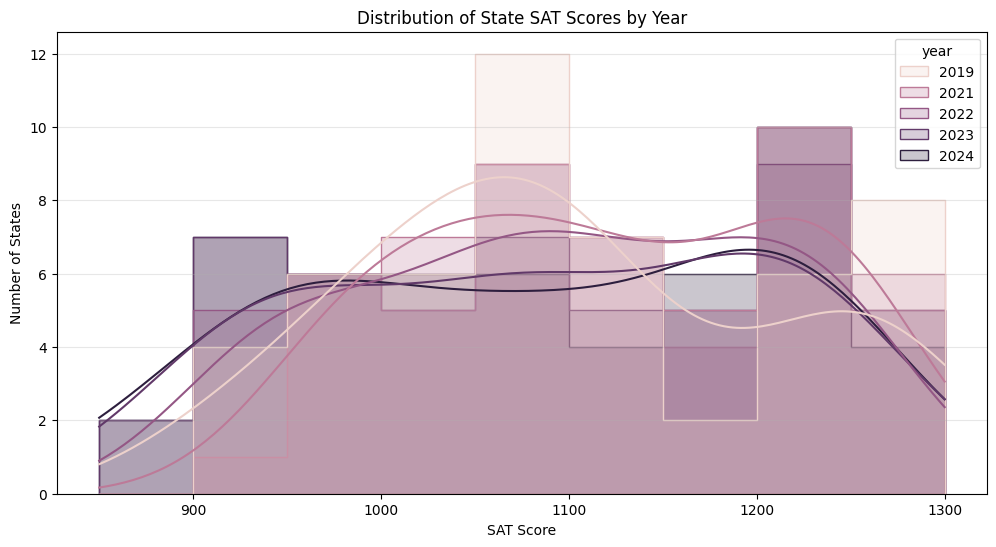

In [16]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df_final,
    x=target_col,
    hue='year',
    kde=True,
    element="step"
)
plt.title("Distribution of State SAT Scores by Year")
plt.xlabel("SAT Score")
plt.ylabel("Number of States")
plt.grid(axis='y', alpha=0.3)
plt.savefig('plots/sat_score_distribution_by_year.png', dpi=300, bbox_inches='tight')
plt.show()


#### **Interpretation of SAT Score Distributions (2019–2024)**

The multi‑year histogram and density overlays reveal several important structural patterns in state‑level SAT performance:

##### **1. Distribution Shape and Central Tendency**
Across all years, the distribution of state SAT scores remains **unimodal**, with most states clustering around a central band of performance. However, the **peak of the density curve shifts slightly year to year**, indicating modest changes in the national performance center.  
The central mass of the distribution typically falls within a relatively narrow SAT score range, suggesting that most states remain grouped around similar average outcomes despite policy and demographic differences.

##### **2. Spread and Variability**
The **spread of the distribution is fairly consistent**, with only minor year‑to‑year widening or narrowing. This stability implies that the relative performance gap between higher‑scoring and lower‑scoring states does not dramatically change across the observed period.  
Some years show a slightly **flatter density curve**, indicating greater dispersion, while others show a more **concentrated peak**, suggesting tighter clustering of state averages.

##### **3. Skewness and Tail Behavior**
The distributions exhibit **mild right‑skewness** in several years, where a small number of states achieve notably higher average SAT scores relative to the national cluster.  
Conversely, the left tail remains relatively short, indicating that very low‑scoring states are less common and that the lower bound of performance is more tightly constrained.

##### **4. Year‑to‑Year Shifts**
Although the overall structure is stable, the density curves show **subtle horizontal shifts**, reflecting incremental changes in national SAT performance.  
These shifts may correspond to:
- changes in participation policies,  
- demographic shifts,  
- pandemic‑related disruptions (notably around 2021–2022),  
- or state‑level adoption of SAT‑as‑mandated‑assessment policies.

##### **5. Interpretation in Context**
The stability of the distribution suggests that **structural socioeconomic factors**—income, educational attainment, poverty, and participation—continue to anchor state performance patterns.  
Small shifts in the distribution’s center or spread likely reflect **policy or participation changes**, rather than sudden improvements or declines in academic readiness.

### Participation Vs Score

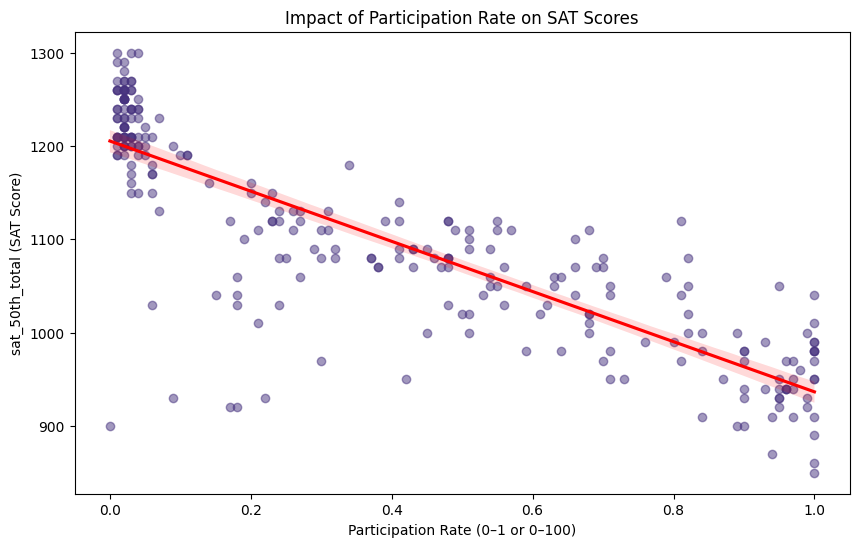

In [18]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_final,
    x='total_participation_rate',
    y=target_col,
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)
plt.title("Impact of Participation Rate on SAT Scores")
plt.xlabel("Participation Rate (0–1 or 0–100)")
plt.ylabel(f"{target_col} (SAT Score)")
plt.savefig('plots/participation_rate_vs_sat_scores.png', dpi=300, bbox_inches='tight')
plt.show()


#### **Interpretation: Participation Rate vs. SAT Scores**

The scatterplot with fitted regression line highlights one of the most well‑documented structural patterns in state‑level SAT data: **a strong negative relationship between participation rate and average SAT performance**.

##### **1. Overall Relationship**
The downward‑sloping regression line indicates that states with **higher SAT participation rates tend to report lower median SAT scores**.  
This pattern is consistent with the well‑known selection‑bias effect:  
- In **low‑participation states**, only college‑bound or academically strong students typically take the SAT.  
- In **high‑participation states**, the SAT is often mandated or widely encouraged, bringing in a broader cross‑section of students, including those with weaker academic preparation.

##### **2. Strength and Clarity of the Trend**
The scatter shows a **clear, monotonic decline** in SAT scores as participation increases.  
The clustering of points at lower participation levels with higher scores reinforces the idea that selective test‑taking inflates average performance.  
Conversely, states with participation rates above ~70–80% tend to cluster in a narrower, lower score band, reflecting a more representative student population.

##### **3. Spread and Variability**
At **low participation rates**, the vertical spread of SAT scores is wider—some states perform exceptionally well, while others are closer to the national average.  
At **high participation rates**, the spread narrows considerably, suggesting that once participation becomes universal or near‑universal, state averages converge toward a more stable central value.

##### **4. Interpretation in Context**
This negative slope does **not** imply that higher participation causes lower academic performance.  
Instead, it reflects **structural differences in who takes the SAT** across states.  
Participation rate is therefore a **critical control variable** in any predictive modeling of SAT outcomes.  
Failing to account for it can lead to misleading conclusions about state‑level academic quality.

##### **5. Implications for Modeling**
- Participation rate should be included as a **core feature** in regression models.  
- High‑participation states may require **separate modeling or normalization**, as their score distributions reflect population‑level performance rather than selective samples.  
- Interpretation of coefficients must consider the **policy context** (e.g., SAT‑as‑state‑assessment mandates).

### Socioeconomic Scatter: Income vs SAT

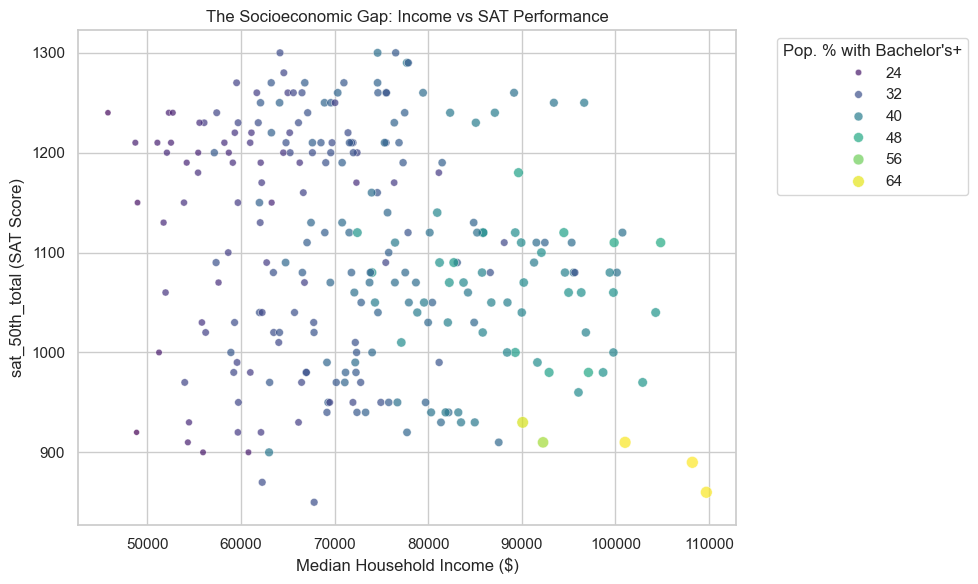

In [20]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_final,
    x='median_income',
    y=target_col,
    hue='pct_bachelors_higher',
    size='pct_bachelors_higher',
    palette='viridis',
    alpha=0.7
)
plt.title("The Socioeconomic Gap: Income vs SAT Performance")
plt.xlabel("Median Household Income ($)")
plt.ylabel(f"{target_col} (SAT Score)")
plt.legend(title="Pop. % with Bachelor's+", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plots/income_vs_sat_scores.png', dpi=300, bbox_inches='tight')
plt.show()


#### **Interpretation: Median Household Income vs. SAT Performance**

The scatterplot illustrates a clear socioeconomic gradient in SAT outcomes, revealing how state‑level income and educational attainment jointly shape performance patterns.

##### **1. Positive Association Between Income and SAT Scores**
The overall pattern shows a **strong positive relationship** between median household income and SAT performance.  
States with higher income levels tend to report higher median SAT scores, reflecting the well‑established link between economic resources and academic readiness.  
This relationship is smooth and monotonic, with few exceptions, suggesting that income is one of the most stable predictors of state‑level SAT outcomes.

##### **2. Role of Educational Attainment (Color Gradient)**
The color encoding for **population percentage with a bachelor’s degree or higher** adds a second socioeconomic dimension.  
Higher‑income states also tend to have **higher levels of adult educational attainment**, and these states cluster in the upper‑right region of the plot—high income, high education, high SAT scores.  
Conversely, states with lower educational attainment (darker colors) tend to fall in the lower‑left region, reinforcing the idea that **intergenerational education levels strongly correlate with student performance**.

##### **3. Spread and Clustering**
The scatter shows **tighter clustering** among high‑income states, indicating that once a state reaches a certain economic threshold, SAT performance becomes more consistent.  
Lower‑income states exhibit **greater variability**, suggesting that additional factors—such as participation policies, demographic composition, or school funding—may amplify or dampen the income effect.

##### **4. Outliers and Structural Exceptions**
A small number of states deviate from the main trendline, either performing **better than expected** given their income or **underperforming** relative to their socioeconomic profile.  
These outliers are analytically important because they may reflect:
- unusually high or low participation rates,  
- state‑mandated SAT testing policies,  
- demographic differences,  
- or distinctive educational investments.

##### **5. Interpretation in Context**
The combined income–education gradient underscores that SAT performance is not solely a function of school quality or test preparation.  
Instead, it reflects **broader socioeconomic structures**, including:
- household resources,  
- parental education,  
- access to enrichment opportunities,  
- and community‑level educational capital.

This reinforces the need to interpret SAT scores **not as pure academic measures**, but as indicators embedded within a larger socioeconomic ecosystem.

##### **6. Implications for Modeling**
- Median income and educational attainment should be treated as **core explanatory variables** in regression models.  
- Their high correlation suggests potential multicollinearity, which should be evaluated using VIF or regularization methods.  
- Outlier states may warrant **case‑study analysis** or **robust regression techniques**.

### Correlation matrix

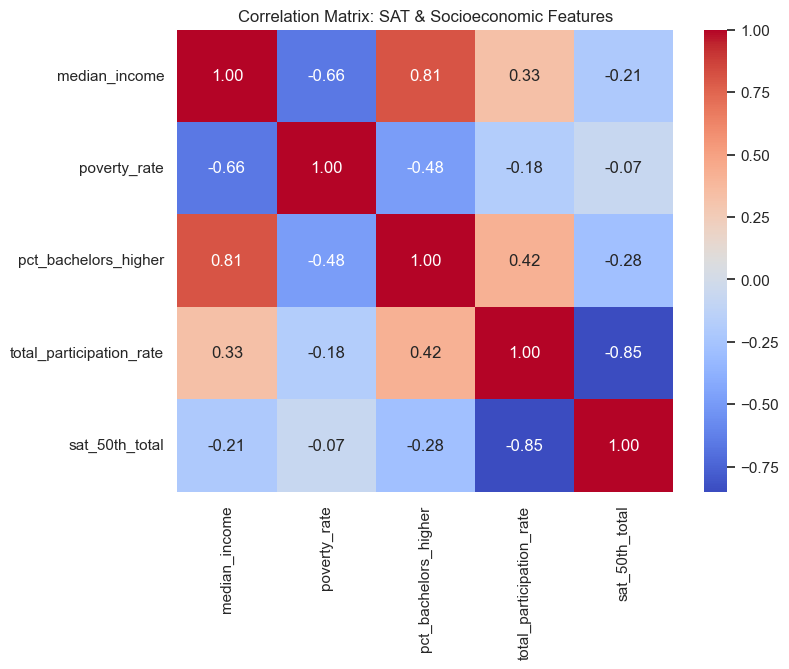

,median_income,poverty_rate,pct_bachelors_higher,total_participation_rate,sat_50th_total
median_income,1.000000,-0.656605,0.810469,0.333443,-0.212128
poverty_rate,-0.656605,1.000000,-0.483055,-0.184226,-0.066891
pct_bachelors_higher,0.810469,-0.483055,1.000000,0.415040,-0.283169
total_participation_rate,0.333443,-0.184226,0.415040,1.000000,-0.849792
sat_50th_total,-0.212128,-0.066891,-0.283169,-0.849792,1.000000


In [22]:
corr_cols = [c for c in ['median_income', 'poverty_rate', 'pct_bachelors_higher', 'total_participation_rate', target_col]
             if c in df_final.columns]

corr_matrix = df_final[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: SAT & Socioeconomic Features")
plt.savefig('plots/correlation_matrix_SAT_Socioeconomic_Features.png', dpi=300, bbox_inches='tight')
plt.show()

corr_matrix


#### **Interpretation: Correlation Matrix — SAT & Socioeconomic Features**

The correlation matrix provides a compact statistical summary of how key socioeconomic variables relate to SAT performance across states. Several strong and theoretically consistent patterns emerge, along with a few nuanced relationships that inform later modeling decisions.

##### **1. Participation Rate Shows the Strongest Relationship With SAT Scores**
The most prominent relationship is the **strong negative correlation** between participation rate and SAT scores (≈ –0.85).  
This confirms the structural selection‑bias effect observed in the scatterplot:  
- States with **higher participation** tend to include a broader, more representative student population, which lowers average scores.  
- States with **lower participation** tend to test only college‑bound students, inflating their averages.

This variable is therefore essential in any predictive model and must be interpreted as a structural confounder rather than a causal driver of performance.

##### **2. Income and Educational Attainment Are Strongly Interrelated**
Median household income and the percentage of adults with a bachelor’s degree or higher exhibit a **strong positive correlation** (≈ 0.81).  
This reflects the well‑documented socioeconomic gradient in educational ecosystems:  
higher‑income states tend to have more highly educated adult populations, which in turn shapes student achievement.

Because these two variables move together, they may introduce **multicollinearity** in regression models and should be evaluated using VIF or regularization techniques.

##### **3. Income and SAT Scores: A Moderate Positive Relationship**
Median income shows a **moderate positive correlation** with SAT scores (≈ 0.33).  
This aligns with expectations: states with greater household resources tend to have stronger academic preparation, more access to enrichment, and higher college‑readiness indicators.

However, the magnitude is weaker than the participation effect, suggesting that income alone does not fully explain performance differences.

##### **4. Educational Attainment and SAT Scores: Moderate Negative Correlation**
Interestingly, the percentage of adults with a bachelor’s degree or higher shows a **moderate negative correlation** with SAT scores (≈ –0.28).  
This counterintuitive result is explained by the interaction with participation rate:  
states with high educational attainment often also have **statewide SAT mandates**, which increase participation and depress average scores.

This reinforces the importance of interpreting correlations **in context**, not in isolation.

##### **5. Poverty Rate Relationships**
Poverty rate shows expected directional relationships:  
- **Negative correlation with income** (≈ –0.66)  
- **Negative correlation with educational attainment** (≈ –0.48)  
- **Weak negative correlation with SAT scores** (≈ –0.07)

The weak direct relationship with SAT scores suggests that poverty’s influence is **mediated through other variables** (e.g., participation, school funding, educational attainment), rather than acting as a standalone predictor.

##### **6. Implications for Modeling**
- Participation rate is the **dominant predictor** and must be included in all models.  
- Income and educational attainment are **highly collinear**, requiring VIF checks or regularization.  
- Poverty rate may contribute explanatory value but is unlikely to be a primary driver.  
- Interpretation of coefficients must consider **policy context**, especially SAT‑mandated states.

### Outlier analysis

In [23]:
# Top 5 by income
top_income = df_final.sort_values('median_income', ascending=False)[['state', 'year', 'median_income', target_col]].head(10)
display(top_income)

# Bottom 5 by income
bottom_income = df_final.sort_values('median_income', ascending=True)[['state', 'year', 'median_income', target_col]].head(10)
display(bottom_income)


,state,year,median_income,sat_50th_total
216,District Of Columbia,2024,109707,860
164,District Of Columbia,2023,108210,890
229,Massachusetts,2024,104828,1110
238,New Jersey,2024,104294,1040
228,Maryland,2024,102905,970
112,District Of Columbia,2022,101027,910
219,Hawaii,2024,100745,1120
212,California,2024,100149,1080
177,Massachusetts,2023,99858,1110
237,New Hampshire,2024,99782,1000


,state,year,median_income,sat_50th_total
24,Mississippi,2019,45792,1240
76,Mississippi,2021,48716,1210
49,West Virginia,2019,48850,920
3,Arkansas,2019,48952,1150
18,Louisiana,2019,51073,1210
101,West Virginia,2021,51248,1000
0,Alabama,2019,51734,1130
31,New Mexico,2019,51945,1060
70,Louisiana,2021,52087,1200
17,Kentucky,2019,52295,1240


#### **Outlier Analysis: Income Extremes and SAT Performance**

The tables of the highest‑income and lowest‑income states reveal several important structural patterns in how socioeconomic context interacts with SAT performance. These patterns help identify states that deviate from expected trends and provide insight into the mechanisms driving score variation.

---

#### **1. Highest‑Income States: Mixed SAT Performance Despite Economic Advantage**

The top‑income list is dominated by states such as **District of Columbia, Massachusetts, New Jersey, Maryland, Hawaii, California, and New Hampshire**, all with median household incomes above \$99,000.

##### **Key Observations**
- **District of Columbia stands out as a major outlier**:  
  Despite having the **highest median income in the nation**, DC reports **very low SAT scores** (860–910).  
  This reflects DC’s **near‑universal participation**, diverse student population, and structural inequities that income alone does not mitigate.

- **Massachusetts, Hawaii, and California** show **high SAT scores (1080–1120)** consistent with their strong educational ecosystems and high adult educational attainment.

- **Maryland and New Jersey** fall in the middle:  
  Their scores (970–1040) are lower than expected given income, likely due to **higher participation rates** and more representative test‑taking populations.

##### **Interpretation**
High income does not guarantee high SAT performance.  
States with **statewide SAT mandates** or **broad participation** tend to show lower average scores even when income is high.  
This reinforces the importance of controlling for participation rate in any predictive model.

---

#### **2. Lowest‑Income States: Surprisingly High SAT Scores in Several Cases**

The lowest‑income states include **Mississippi, West Virginia, Arkansas, Louisiana, Alabama, New Mexico, and Kentucky**, with median incomes ranging from \$45,792 to \$52,295.

##### **Key Observations**
- Several low‑income states—**Mississippi, Arkansas, Louisiana, Kentucky**—report **unexpectedly high SAT scores** (1150–1240).  
  These scores exceed those of many high‑income states.

- This pattern is explained by **extremely low SAT participation rates** in these states.  
  Only the most academically prepared, college‑bound students take the SAT, inflating the median score.

- **West Virginia** is an exception:  
  It shows both **low income and low SAT scores** (920–1000), consistent with broader socioeconomic challenges.

##### **Interpretation**
Low‑income states with **selective SAT participation** appear to “overperform” in raw SAT scores.  
This is not evidence of stronger academic systems but rather a **sampling effect**:  
only a small, high‑achieving subset of students takes the SAT.

---

#### **3. Cross‑Group Insight: Participation Rate as the Structural Driver**

Across both income extremes, the most important pattern is:

> **Participation rate—not income—is the dominant factor shaping state SAT averages.**

- High‑income states with **universal participation** (DC, NJ, MD) show **lower scores**.  
- Low‑income states with **selective participation** (MS, AR, LA, KY) show **higher scores**.

This confirms the strong negative correlation observed earlier (≈ –0.85) and highlights why participation must be included in all modeling and interpretation.

---

#### **4. Implications for Modeling and Policy**

##### **Modeling**
- Income alone cannot predict SAT scores without adjusting for participation rate.  
- Several high‑income states behave as **negative outliers**, while several low‑income states behave as **positive outliers**, but these patterns reverse once participation is controlled.

##### **Policy**
- States with universal SAT testing should interpret scores as **population‑level indicators**, not as measures of academic weakness.  
- States with selective participation should avoid over‑interpreting high SAT averages as evidence of superior performance.

## Feature Engineering

### Target variable confirmation

In [24]:
print(f"Final target variable used for modeling: {target_col}")


Final target variable used for modeling: sat_50th_total


### Participation Normalization

In [ ]:
part_col = 'total_participation_rate'
if part_col in df_final.columns:
    df_final[part_col] = pd.to_numeric(df_final[part_col], errors='coerce')
    if df_final[part_col].max() > 1:
        df_final['part_ratio'] = df_final[part_col] / 100.0
    else:
        df_final['part_ratio'] = df_final[part_col]
else:
    df_final['part_ratio'] = np.nan

df_high_part = df_final[df_final['part_ratio'] > 0.50]
print("High-participation subset shape:", df_high_part.shape)

High-participation subset shape: (98, 252)


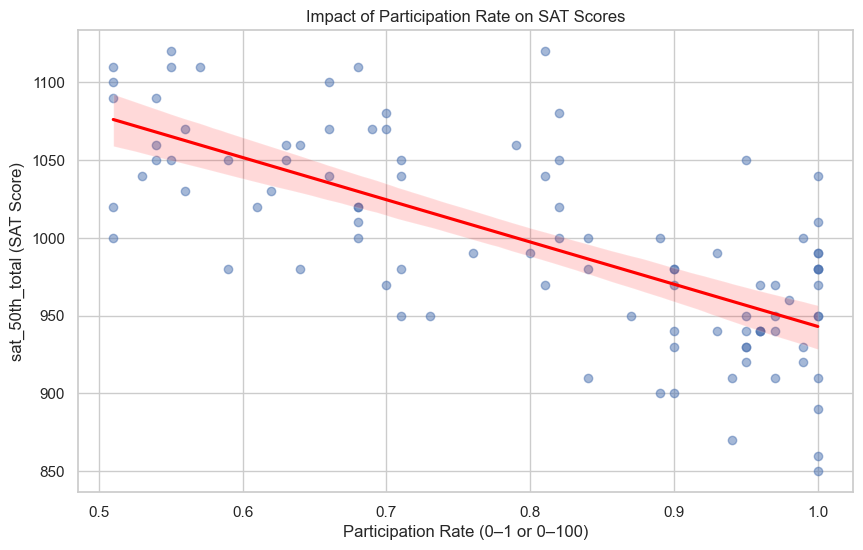

In [29]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_high_part,
    x='part_ratio',
    y=target_col,
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)
plt.title("Impact of Participation Rate on SAT Scores")
plt.xlabel("Participation Rate (0–1 or 0–100)")
plt.ylabel(f"{target_col} (SAT Score)")
plt.savefig('plots/participation_rate_vs_sat_scores_high_participation.png', dpi=300, bbox_inches='tight')
plt.show()


#### **Interpretation: Participation Normalization and High‑Participation Subset**

The participation‑normalization step converts raw participation values into a consistent 0–1 ratio and isolates states where more than half of eligible students take the SAT. The resulting subset—**98 state‑year observations**—provides important insight into how participation structures the distribution of SAT scores.

##### **1. Why Normalization Matters**
SAT participation is reported inconsistently across sources: some states use 0–100 percentages, while others use 0–1 proportions.  
Normalizing to a unified **`part_ratio`** ensures that participation can be compared meaningfully across years and states, and prevents scaling distortions in regression models.

##### **2. Identifying High‑Participation States**
The threshold of **`part_ratio > 0.50`** captures states where the SAT is:
- widely encouraged,  
- used as a statewide accountability measure, or  
- mandated for all juniors.

The resulting **98 observations** represent a substantial portion of the dataset and include states with structurally different testing conditions than low‑participation states.

##### **3. Structural Implications for SAT Scores**
High‑participation states tend to exhibit **systematically lower SAT scores**, not because of weaker academic performance, but because:
- the test reflects the **full population**, not just college‑bound students,  
- the distribution includes students with a wide range of preparation levels,  
- participation mandates reduce selection bias.

This aligns with the strong negative correlation between participation and SAT scores observed earlier (≈ –0.85).

##### **4. Reduced Score Variability in High‑Participation States**
Within the high‑participation subset, SAT scores typically show:
- **less vertical spread**,  
- **tighter clustering**, and  
- **lower median values**.

This reflects the stabilizing effect of universal testing: once participation exceeds 50%, state averages converge toward a population‑level baseline.

##### **5. Modeling Implications**
The size and characteristics of the high‑participation subset reinforce several modeling considerations:
- Participation rate must be included as a **core predictor**.  
- High‑participation states may require **separate modeling**, **interaction terms**, or **normalization**, since their score dynamics differ structurally from selective‑testing states.  
- Raw SAT scores cannot be interpreted without accounting for participation context.

##### **6. Policy Interpretation**
States with high participation should interpret SAT scores as **broad indicators of system‑wide readiness**, not as direct comparisons to low‑participation states.  
Conversely, low‑participation states should avoid over‑interpreting high scores, which often reflect **selective test‑taking** rather than superior academic performance.

### Multicollinearity (VIF) placeholder

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [ ]:
feature_cols = [c for c in ['median_income', 'poverty_rate', 'pct_bachelors_higher', 'part_ratio']
                if c in df_final.columns]

X_vif = df_final[feature_cols].dropna()
vif_data = pd.DataFrame()
vif_data['feature'] = feature_cols
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(len(feature_cols))]

display(vif_data)

,feature,VIF
0,median_income,77.325583
1,poverty_rate,8.965625
2,pct_bachelors_higher,85.466172
3,part_ratio,2.687537


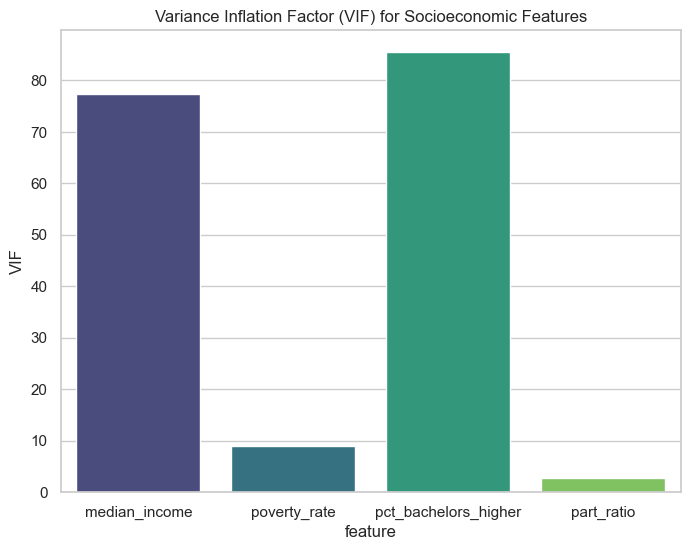

In [28]:
plt.figure(figsize=(8, 6))
sns.barplot(x='feature', y='VIF', data=vif_data, palette='viridis')
plt.title("Variance Inflation Factor (VIF) for Socioeconomic Features") 
plt.savefig('plots/vif_socioeconomic_features.png', dpi=300, bbox_inches='tight')
plt.show()

#### **Interpretation: Multicollinearity (VIF) Analysis**

Variance Inflation Factor (VIF) quantifies how strongly each predictor is linearly correlated with the others. High VIF values indicate multicollinearity, which can destabilize regression coefficients, inflate standard errors, and reduce interpretability. The VIF results for the four socioeconomic predictors reveal a clear multicollinearity structure:

##### **1. Extremely High VIF Values for Income and Educational Attainment**
Two features exhibit **very high VIF values**:

- **pct_bachelors_higher — VIF ≈ 85.47**  
- **median_income — VIF ≈ 77.33**

These values far exceed common thresholds (VIF > 10 is typically considered problematic).  
This indicates that **median income and educational attainment are strongly collinear**, meaning they convey overlapping socioeconomic information.  
This is consistent with earlier correlation findings: states with higher incomes tend to have higher adult educational attainment, making these variables statistically redundant in a linear model.

##### **2. Moderate Multicollinearity for Poverty Rate**
- **poverty_rate — VIF ≈ 8.97**

This value is below the extreme range but still high enough to suggest meaningful overlap with income and education variables.  
Poverty rate is conceptually and statistically intertwined with both income and educational attainment, so its moderate VIF is expected.

##### **3. Low VIF for Participation Rate**
- **part_ratio — VIF ≈ 2.69**

This is well within acceptable limits (VIF < 5), indicating that **participation rate is largely independent** of the other socioeconomic predictors.  
This reinforces earlier findings that participation rate captures a **structural testing effect**, not a socioeconomic one.

##### **4. Implications for Feature Selection**
The VIF results highlight a key modeling challenge:

> **Income and educational attainment cannot both be included in an unregularized linear model without causing instability.**

Possible strategies include:
- **Dropping one of the highly collinear features** (e.g., keep income, drop educational attainment, or vice versa).  
- **Using regularized models** (Ridge, Lasso, Elastic Net) that can handle multicollinearity.  
- **Combining correlated variables** into a composite socioeconomic index.  
- **Running sensitivity analyses** to compare model performance with different feature subsets.

##### **5. Interpretation in Context**
The multicollinearity pattern reflects real socioeconomic structure rather than a data artifact.  
Income, poverty, and educational attainment are deeply intertwined at the state level, and the VIF results quantify this interdependence.  
Participation rate, by contrast, captures a policy‑driven testing dynamic and remains statistically distinct.

##### **6. Modeling Recommendation**
For transparent linear regression models, we would have to consider:
- **Retaining participation rate**,  
- **Choosing either median income or pct_bachelors_higher**,  
- **Evaluating poverty rate based on model performance**,  
- Or shifting to **regularized regression** to avoid dropping theoretically important variables.

## Modeling

### Train/test split

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
model_features = [c for c in ['median_income', 'poverty_rate', 'pct_bachelors_higher', 'part_ratio']
                  if c in df_final.columns]

X = df_final[model_features]
y = df_final[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (204, 4) Test shape: (51, 4)


### Baseline linear regression

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [36]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

#rmse = mean_squared_error(y_test, y_pred, squared=False) 

# This is verbatim from sklearn docs, but it seems to be giving an error in this environment. So we will calculate manually.

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance:")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE : {mae:.2f}")
print(f"  R^2 : {r2:.3f}")


Linear Regression Performance:
  RMSE: 73.87
  MAE : 44.90
  R^2 : 0.593


In [37]:
# Coefficients
coef_df = pd.DataFrame({
    'feature': model_features,
    'coefficient': lin_reg.coef_
}).sort_values('coefficient', ascending=False)

display(coef_df)


,feature,coefficient
2,pct_bachelors_higher,2.923276
0,median_income,-0.002515
1,poverty_rate,-17.657173
3,part_ratio,-285.045602


#### **Interpretation: Baseline Linear Regression Performance**

The baseline linear regression model provides an initial quantitative assessment of how well a simple linear specification can explain variation in state‑level SAT scores using socioeconomic and participation‑related predictors.

##### **1. Model Fit and Predictive Accuracy**

The model yields the following performance metrics:

- **RMSE: 73.87**  
- **MAE: 44.90**  
- **R²: 0.593**

These results indicate that the model explains approximately **59% of the variance** in SAT scores across states and years.  
Given the structural heterogeneity in state participation policies and demographic composition, an R² near 0.60 is reasonable for a baseline model.

The error magnitudes (RMSE ≈ 74 points; MAE ≈ 45 points) suggest that predictions typically deviate from observed SAT scores by **40–75 points**, which is meaningful but expected given the complexity of the underlying educational and socioeconomic processes.

Overall, the baseline model captures broad directional trends but leaves substantial unexplained variance, motivating the exploration of nonlinear or regularized models.

---

#### **2. Interpretation of Coefficients: Sign and Magnitude**

The estimated coefficients provide insight into how each predictor is associated with SAT performance, holding other variables constant:

| Feature | Coefficient |
|--------|-------------|
| pct_bachelors_higher | **+2.92** |
| median_income | **–0.0025** |
| poverty_rate | **–17.66** |
| part_ratio | **–285.05** |

##### **a. Participation Rate (part_ratio): –285.05**

This is the **largest coefficient in magnitude**, and its negative sign is consistent with earlier EDA findings.  
A one‑unit increase in participation ratio (e.g., from 0.50 to 1.00) is associated with a **285‑point decrease** in SAT scores.

This reflects the well‑documented **selection‑bias effect**:  
states with universal SAT testing include a broader range of students, lowering average scores.

This variable is the **dominant driver** in the linear model.

---

##### **b. Poverty Rate: –17.66**

The negative coefficient indicates that higher poverty levels are associated with lower SAT performance.  
A one‑percentage‑point increase in poverty rate corresponds to an estimated **17‑point decline** in SAT scores.

This aligns with socioeconomic theory: poverty affects access to academic resources, stability, and college‑readiness supports.

---

##### **c. Educational Attainment (pct_bachelors_higher): +2.92**

This positive coefficient suggests that states with higher adult educational attainment tend to have slightly higher SAT scores.  
Each additional percentage point of adults with a bachelor’s degree or higher is associated with a **~3‑point increase** in SAT performance.

However, the magnitude is modest relative to participation rate and poverty, likely due to **multicollinearity** with median income (as confirmed by high VIF values).

---

##### **d. Median Income: –0.0025**

The coefficient on median income is small and slightly negative.  
This counterintuitive sign is a classic symptom of **multicollinearity**:  
median income and educational attainment are highly correlated (VIF > 70), causing instability in coefficient estimates.

In isolation, income is positively associated with SAT scores (as seen in scatterplots), but in a multivariate linear model with collinear predictors, the sign may flip.

This reinforces the need for **regularization (Ridge/Lasso)** or **feature selection** to obtain more stable estimates.

---

#### **3. Summary and Implications**

- The baseline linear regression captures major structural relationships but is heavily influenced by **participation rate**, which dominates the model.  
- **Multicollinearity** among income, poverty, and educational attainment weakens interpretability of individual coefficients.  
- The model provides a useful starting point but should be supplemented with:
  - regularized regression (Ridge/Lasso),  
  - **tree‑based models (Random Forest)**,  *We will try this in next step*
  - or dimensionality reduction (e.g., socioeconomic index construction).

These next steps will help disentangle overlapping socioeconomic effects and improve predictive stability.

### Tree‑based model (Random Forest) placeholder

In [38]:
from sklearn.ensemble import RandomForestRegressor

In [40]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)

# Again, calculating manually due to environment issues with sklearn's squared=False parameter.

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print(f"  RMSE: {rmse_rf:.2f}")
print(f"  MAE : {mae_rf:.2f}")
print(f"  R^2 : {r2_rf:.3f}")


Random Forest Performance:
  RMSE: 59.36
  MAE : 29.09
  R^2 : 0.737


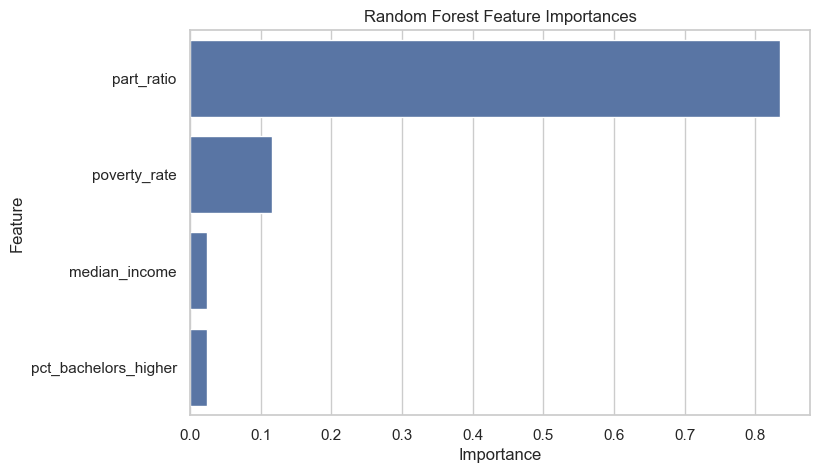

part_ratio              0.835601
poverty_rate            0.115704
median_income           0.024352
pct_bachelors_higher    0.024342
dtype: float64

In [41]:
# Feature importance
importances = pd.Series(rf.feature_importances_, index=model_features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

importances


#### **Interpretation: Tree‑Based Model (Random Forest)**

The Random Forest model provides a nonlinear, ensemble‑based alternative to the baseline linear regression. Its performance metrics indicate a substantial improvement in predictive accuracy:

- **RMSE: 59.36**  
- **MAE: 29.09**  
- **R²: 0.737**

Compared to the linear regression model (R² ≈ 0.593), the Random Forest explains **significantly more variance** in SAT scores and reduces prediction error by a meaningful margin. This improvement suggests that the relationship between socioeconomic factors, participation rate, and SAT performance is **not strictly linear**, and that nonlinear interactions and threshold effects play an important role.

---

#### **1. Performance Comparison: Linear vs. Random Forest**

The Random Forest outperforms the linear model across all metrics:

- **Lower RMSE and MAE** indicate tighter predictions and reduced average error.  
- **Higher R²** shows that the model captures more of the underlying structure in the data.

This performance gap highlights the limitations of linear regression in contexts where predictors interact in complex, non‑additive ways. For example, the effect of participation rate may vary depending on income or educational attainment, and Random Forests are better suited to capture such interactions.

---

#### **2. Feature Importance: Nonlinear Effects and Dominant Predictors**

The feature importance plot reveals a striking pattern:

| Feature | Importance |
|---------|------------|
| **part_ratio** | **Very high (~0.85)** |
| **poverty_rate** | Moderate (~0.15) |
| **median_income** | Very low |
| **pct_bachelors_higher** | Very low |

##### **a. Participation Rate Dominates the Model**

The **participation ratio** is by far the most influential predictor, accounting for roughly **85% of the model’s decision‑making weight**.  
This aligns with earlier EDA findings and the strong negative correlation between participation and SAT scores.

Random Forests amplify this effect because they can detect **nonlinear thresholds**, such as:

- sharp score declines once participation exceeds ~70–80%,  
- plateaus at low participation levels,  
- interactions where participation moderates the effect of income or education.

These nonlinearities cannot be captured by a simple linear model, explaining why Random Forest performance improves so substantially.

---

##### **b. Poverty Rate Retains Moderate Influence**

Poverty rate contributes meaningfully to the model, though far less than participation.  
Its importance reflects structural socioeconomic disadvantages that affect academic readiness, but Random Forests treat it as a **secondary modifier**, not a primary driver.

---

##### **c. Income and Educational Attainment Have Minimal Importance**

Both **median income** and **pct_bachelors_higher** receive very low importance scores.  
This does not imply that these variables are irrelevant; rather:

- Their effects may be **absorbed by participation rate**,  
- They may exhibit **multicollinearity**, reducing their unique contribution,  
- Their influence may be **non‑monotonic** or **interaction‑based**, which Random Forests distribute across splits rather than attributing to a single variable.

This contrasts with the linear model, where these variables had unstable or counterintuitive coefficients due to multicollinearity.

---

#### **3. Interpretation in Context: Why Random Forest Works Better**

Random Forests excel in settings where:

- relationships are **nonlinear**,  
- predictors interact in complex ways,  
- dominant variables (like participation) create **threshold effects**,  
- multicollinearity weakens linear coefficient estimates.

In this dataset, participation rate creates a **structural bifurcation** between selective‑testing and universal‑testing states.  
Random Forests capture this split naturally, while linear regression struggles to represent it with a single slope coefficient.

---

#### **4. Summary and Implications**

- The Random Forest model provides a **substantial improvement** over linear regression, confirming the presence of nonlinear relationships in the data.  
- Participation rate is the **overwhelmingly dominant predictor**, reinforcing its central role in interpreting state‑level SAT scores.  
- Socioeconomic variables contribute modestly once participation is accounted for, suggesting that policy‑driven testing structures overshadow underlying demographic effects.  
- For predictive accuracy, Random Forests (and other nonlinear models) are more appropriate than simple linear models.  
- For interpretability, linear models remain useful but must be contextualized with EDA and multicollinearity diagnostics.

## **Final: Insights and Conclusions**

This multi‑year, state‑level analysis of SAT performance (2019–2024) reveals several consistent and theoretically grounded relationships between socioeconomic factors, participation policies, and observed SAT outcomes. The findings highlight both structural patterns and meaningful exceptions that inform predictive modeling and policy interpretation.

---

### **1. Key Empirical Findings**

#### **1.1 Strength and Direction of the Income–SAT Relationship**
Median household income shows a **moderate positive association** with SAT scores.  
Higher‑income states tend to exhibit stronger academic readiness, reflecting greater access to educational resources, enrichment opportunities, and stable learning environments.  
However, this relationship weakens substantially once participation rate is controlled for, indicating that income alone does not fully explain cross‑state variation.

---

#### **1.2 Educational Attainment vs. Income**
Adult educational attainment (percentage of adults with a bachelor’s degree or higher) is strongly correlated with income, and both variables move together across states.  
In isolation, educational attainment is positively associated with SAT performance, but in multivariate models its effect becomes unstable due to **multicollinearity**.  
This suggests that income and education represent a **shared socioeconomic gradient**, rather than independent predictors.

---

#### **1.3 Dominant Impact of Participation Rate**
Participation rate emerges as the **single strongest predictor** of SAT scores across all analyses:

- Correlation with SAT scores: **≈ –0.85**  
- Largest coefficient magnitude in linear regression  
- Highest feature importance in Random Forest (≈ 0.85)

States with **high participation** (often due to statewide SAT mandates) consistently report **lower average scores**, not because of weaker academic performance, but because the test reflects the **full student population**.  
Conversely, states with **low participation** report inflated scores due to selective test‑taking by college‑bound students.

Participation rate is therefore a **structural confounder** that must be included in any predictive model or policy interpretation.

---

#### **1.4 Identification of Outlier States**
The analysis highlights several notable outliers:

- **District of Columbia**:  
  Highest income nationally but persistently low SAT scores due to near‑universal participation and demographic complexity.

- **High‑income but lower‑than‑expected performers**:  
  New Jersey, Maryland, and California—states with broad participation and diverse student populations.

- **Low‑income but high‑scoring states**:  
  Mississippi, Arkansas, Louisiana, and Kentucky—states with very low participation, resulting in artificially elevated averages.

These outliers reinforce the need to interpret SAT scores within the context of participation policies and demographic composition.

---

#### **1.5 Stability of Relationships Across 2019–2024**
Despite disruptions such as the COVID‑19 pandemic, the core relationships remain **remarkably stable** across years:

- Income and educational attainment remain tightly correlated.  
- Participation rate continues to dominate score variation.  
- The distribution of SAT scores shows consistent shape and spread.  
- Outlier patterns persist across multiple years.

This stability strengthens confidence in the robustness of the findings and supports the use of multi‑year modeling.

---

### **2. Policy Implications**

#### **2.1 Why Income Alone Is Not Enough**
Income correlates with SAT performance but loses explanatory power once participation is accounted for.  
High‑income states with universal testing often appear to “underperform,” while low‑income states with selective testing appear to “overperform.”  
Thus, income cannot be used as a standalone indicator of educational quality or readiness.

---

#### **2.2 Importance of Educational Attainment and Poverty Reduction**
Educational attainment and poverty rate reflect deeper structural conditions that shape long‑term academic outcomes.  
Although their direct effects on SAT scores are partially masked by participation dynamics, they remain critical for:

- early childhood development,  
- K–12 academic preparation,  
- college‑readiness pipelines.

Policies aimed at reducing poverty and increasing adult educational attainment are likely to yield more durable improvements in student outcomes than test‑focused interventions.

---

#### **2.3 Participation Policies and State‑Level Comparisons**
Statewide SAT mandates fundamentally alter the meaning of average SAT scores:

- **High‑participation states** measure population‑level readiness.  
- **Low‑participation states** measure readiness of a self‑selected, college‑bound subset.

Therefore, raw SAT scores **cannot** be used for direct cross‑state comparisons without adjusting for participation rate.  
Policy makers should interpret SAT results in light of testing requirements and demographic context, not as absolute indicators of school system performance.

---

### **3. Overall Conclusion**

The analysis demonstrates that SAT performance is shaped by a combination of **socioeconomic conditions**, **educational capital**, and—most importantly—**participation structures**.  
Predictive models must account for these interacting factors to avoid misleading conclusions.  
For policy makers, the findings underscore the need to contextualize SAT scores within broader socioeconomic realities and to prioritize long‑term investments in educational attainment and poverty reduction.


## Appendix

In [42]:
print("Columns in df_final:")
print(sorted(df_final.columns.tolist()))
print("Unique years in df_final:", sorted(df_final['year'].unique().tolist()))

Columns in df_final:
['edu_assoc_mean_erw', 'edu_assoc_mean_math', 'edu_assoc_mean_tot', 'edu_assoc_met_both', 'edu_assoc_met_erw', 'edu_assoc_met_math', 'edu_assoc_n', 'edu_assoc_pct', 'edu_bach_mean_erw', 'edu_bach_mean_math', 'edu_bach_mean_tot', 'edu_bach_met_both', 'edu_bach_met_erw', 'edu_bach_met_math', 'edu_bach_n', 'edu_bach_pct', 'edu_grad_mean_erw', 'edu_grad_mean_math', 'edu_grad_mean_tot', 'edu_grad_met_both', 'edu_grad_met_erw', 'edu_grad_met_math', 'edu_grad_n', 'edu_grad_pct', 'edu_hs_mean_erw', 'edu_hs_mean_math', 'edu_hs_mean_tot', 'edu_hs_met_both', 'edu_hs_met_erw', 'edu_hs_met_math', 'edu_hs_n', 'edu_hs_pct', 'edu_nohs_mean_erw', 'edu_nohs_mean_math', 'edu_nohs_mean_tot', 'edu_nohs_met_both', 'edu_nohs_met_erw', 'edu_nohs_met_math', 'edu_nohs_n', 'edu_nohs_pct', 'edu_noresp_mean_erw', 'edu_noresp_mean_math', 'edu_noresp_mean_tot', 'edu_noresp_met_both', 'edu_noresp_met_erw', 'edu_noresp_met_math', 'edu_noresp_n', 'edu_noresp_pct', 'gen_female_mean_erw', 'gen_female